# 10 — CO2 transport and storage agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/10_co2_transport_storage_agent.ipynb)

Screen impurity-sensitive dense-phase transport and injection constraints with one traceable chain model.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** CO2 composition envelope, inlet state, pipeline geometry,
injection pressure, reservoir properties, and operating limits.
**Outputs:** phase/property map, pressure margins, injectivity, impurity
sensitivity, and required detailed studies.

Pipeline pressure drop uses the Darcy screen
$\Delta p=f(L/D)\rho v^2/2$; radial injectivity is evaluated with a
steady Darcy-law proxy.

Deep dive: [CO2 compression to pipeline](../../process/co2_chain_from_compression_to_pipeline.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
co2_base = {"CO2": 0.970, "nitrogen": 0.020, "methane": 0.0099, "water": 0.0001}
rows = []
for temperature_c in [5.0, 20.0, 35.0]:
    for pressure_bara in [85.0, 105.0, 125.0]:
        state = flash_state(co2_base, pressure_bara, temperature_c, model="pr")
        rows.append(
            {
                "temperature_c": temperature_c,
                "pressure_bara": pressure_bara,
                "density_kg_m3": state["density_kg_m3"],
                "viscosity_mpa_s": 1000.0 * state["viscosity_pa_s"],
                "phase_count": len(state["phases"]),
            }
        )
property_map = pd.DataFrame(rows)
display(property_map)


,temperature_c,pressure_bara,density_kg_m3,viscosity_mpa_s,phase_count
0,5.0,85.0,858.077644,0.080998,1
1,5.0,105.0,881.095517,0.086263,1
2,5.0,125.0,900.658344,0.091054,1
3,20.0,85.0,715.669459,0.060863,1
4,20.0,105.0,763.124781,0.067586,1
5,20.0,125.0,797.437517,0.073153,1
6,35.0,85.0,369.803783,0.035063,1
7,35.0,105.0,586.902023,0.049697,1
8,35.0,125.0,662.893620,0.057053,1


In [4]:
scenarios = {
    "base 3% impurity": co2_base,
    "medium 6% impurity": {"CO2": 0.940, "nitrogen": 0.040, "methane": 0.0199, "water": 0.0001},
    "high 10% impurity": {"CO2": 0.900, "nitrogen": 0.065, "methane": 0.0349, "water": 0.0001},
}
length_m, diameter_m, roughness_f = 120e3, 0.40, 0.018
inlet_bar, mass_rate_kg_s = 115.0, 105.0
area_m2 = math.pi * diameter_m**2 / 4.0
scenario_rows = []
for name, composition in scenarios.items():
    state = flash_state(composition, inlet_bar, 20.0, model="pr")
    velocity = mass_rate_kg_s / state["density_kg_m3"] / area_m2
    delta_p_bar = (
        roughness_f
        * length_m
        / diameter_m
        * state["density_kg_m3"]
        * velocity**2
        / 2.0
        / 1e5
    )
    outlet_bar = inlet_bar - delta_p_bar
    scenario_rows.append(
        {
            "scenario": name,
            "density_kg_m3": state["density_kg_m3"],
            "viscosity_pa_s": state["viscosity_pa_s"],
            "velocity_m_s": velocity,
            "outlet_bar": outlet_bar,
            "transport_pass": outlet_bar >= 80.0,
        }
    )
transport = pd.DataFrame(scenario_rows)
display(transport)


,scenario,density_kg_m3,viscosity_pa_s,velocity_m_s,outlet_bar,transport_pass
0,base 3% impurity,781.399835,0.000070,1.069316,90.876000,True
1,medium 6% impurity,733.401192,0.000064,1.139299,89.297165,True
2,high 10% impurity,665.015019,0.000055,1.256458,86.654039,True


In [5]:
permeability_m2 = 2000e-3 * 9.869233e-16
thickness_m = 45.0
injector_count = 18
re_m, rw_m = 1200.0, 0.12
reservoir_bar = 185.0
injection_bar = 245.0
base = transport.iloc[0]
volumetric_m3_s = (
    2.0
    * math.pi
    * permeability_m2
    * thickness_m
    * (injection_bar - reservoir_bar)
    * 1e5
    / (base.viscosity_pa_s * (math.log(re_m / rw_m) - 0.75))
)
injectivity_kg_s = volumetric_m3_s * base.density_kg_m3 * injector_count
target_kg_s = 70.0
injection_margin = injectivity_kg_s - target_kg_s
print(f"Injectivity screen for {injector_count} wells={injectivity_kg_s:.1f} kg/s")
print(f"Injection margin={injection_margin:.1f} kg/s")


Injectivity screen for 18 wells=79.0 kg/s
Injection margin=9.0 kg/s


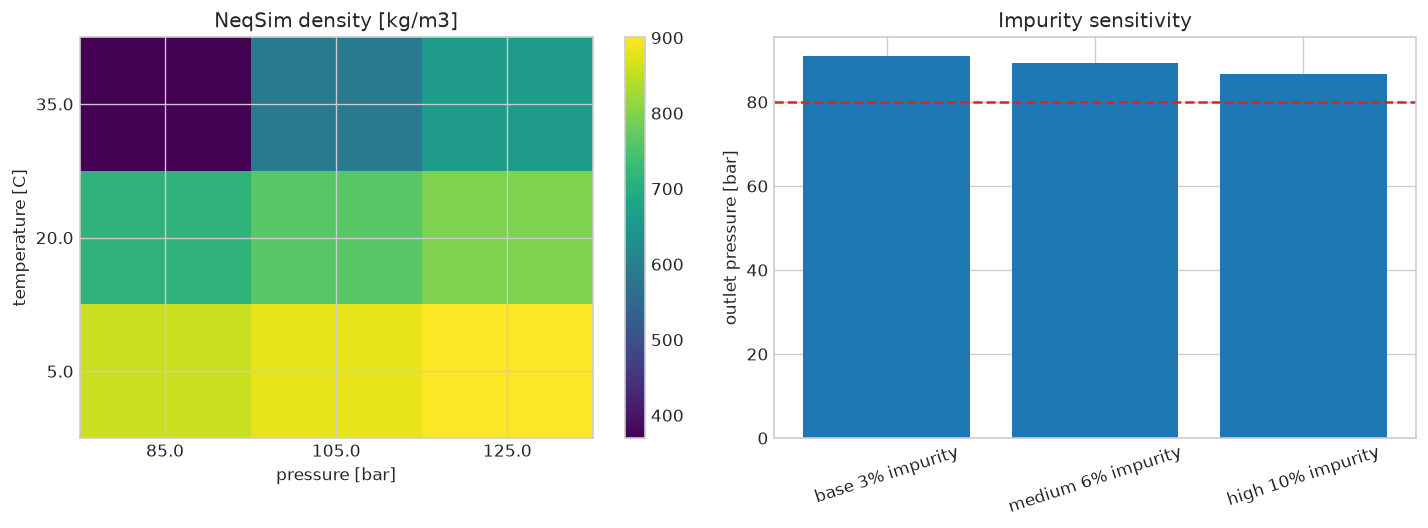

In [6]:
pivot = property_map.pivot(index="temperature_c", columns="pressure_bara", values="density_kg_m3")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
image = axes[0].imshow(pivot.values, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_xticks(range(len(pivot.columns)), pivot.columns)
axes[0].set_yticks(range(len(pivot.index)), pivot.index)
axes[0].set(xlabel="pressure [bar]", ylabel="temperature [C]", title="NeqSim density [kg/m3]")
fig.colorbar(image, ax=axes[0])
axes[1].bar(transport.scenario, transport.outlet_bar)
axes[1].axhline(80, color="tab:red", linestyle="--")
axes[1].set(ylabel="outlet pressure [bar]", title="Impurity sensitivity")
axes[1].tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()


In [7]:
assert bool(transport.iloc[0].transport_pass)
assert transport.outlet_bar.is_monotonic_decreasing
assert injection_margin > 0.0
print("VALIDATION PASSED")
print(
    "Recommendation: preserve impurity envelope and verify phase, "
    "fracture, and transient margins."
)


VALIDATION PASSED
Recommendation: preserve impurity envelope and verify phase, fracture, and transient margins.


## Interpretation and limits

Higher light-gas impurity lowers dense-fluid density and erodes the
transport margin, while the base injectivity screen is positive.
Detailed work must cover phase envelopes, water specification,
corrosion, terrain, heat transfer, transient operations, fracture
pressure, geomechanics, plume behavior, and monitoring.
